In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import platform
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression, Lasso, Ridge
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, mean_squared_error, root_mean_squared_error

sklearn.set_config(display="text")

# 1. 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac OS
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumBarunGothic')

 
# 2. 마이너스 기호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [2]:
base_path = r"C:\kdt_0900_hhj\ml\resource\dataset"
file_name = r"titanic.csv"
file_path = os.path.join(base_path,file_name)

In [3]:
df = pd.read_csv(file_path)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



| 컬럼명 | 데이터 타입 | 설명 및 주요 값 예시 |
| :--- | :---: | :--- |
| **PassengerId** | `int64` | 승객 고유 번호 (1, 2, 3...) |
| **Survived** | `int64` | 생존 여부 (**0**: 사망 / **1**: 생존) |
| **Pclass** | `int64` | 객실 등급 (**1**: 1등석, **2**: 2등석, **3**: 3등석) |
| **Name** | `object` | 승객 이름 (호칭 포함: Mr, Mrs, Miss 등) |
| **Sex** | `object` | 성별 (`male`: 남성 / `female`: 여성) |
| **Age** | `float64` | 승객 나이 (결측치 존재) |
| **SibSp** | `int64` | 함께 탑승한 형제자매/배우자 수 (Siblings / Spouses) |
| **Parch** | `int64` | 함께 탑승한 부모/자녀 수 (Parents / Children) |
| **Ticket** | `object` | 티켓 번호 |
| **Fare** | `float64` | 탑승 요금 |
| **Cabin** | `object` | 객실 번호 (결측치 다수 존재) |
| **Embarked** | `object` | 탑승 항구 (**C**: Cherbourg, **Q**: Queenstown, **S**: Southampton) |

- 타이타닉 승객의 개인 및 탑승 정보(성별, 연령, 객실 등급 등)를 기반으로 생존 여부(survived: 생존 1 / 사망 0)를 예측하는 이진 분류(Binary Classification) 모델을 구축하고자 합니다.

- 입력(특성): 탑승객 인적/탑승 정보 (pclass, sex, age, sibsp, parch, fare, embarked 등)

- 출력(정답): 생존 여부 (1: 생존, 0: 사망)

진행 방향

데이터 수집 → 데이터 전처리 → 데이터 분할 → 모델 학습 → 예측 → 성능 평가

## 1.데이터 전처리

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


생존 여부를 확인하는데 있어서 필요없는 정보는 지우기
: "PassengerId", "Name", "Ticket", "Cabin", "Embarked"
번호,이름,티켓번호,항구 > 생존여부에 영향이 없는 데이터
객실번호 > 객실 위치나 등급 등의 정보에 영향이 있지만, 결측치가 다수 존재해 삭제하는것이 모델을 학습할때 더 좋을 것으로 생각됨

In [5]:
drop_columns = ["PassengerId", "Name", "Ticket", "Cabin", "Embarked"]
titanic_df = df.drop(drop_columns, axis=1)

titanic_df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,0,3,male,22.0,1,0,7.2500
1,1,1,female,38.0,1,0,71.2833
2,1,3,female,26.0,0,0,7.9250
3,1,1,female,35.0,1,0,53.1000
4,0,3,male,35.0,0,0,8.0500
...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000
887,1,1,female,19.0,0,0,30.0000
888,0,3,female,NaN,1,2,23.4500
889,1,1,male,26.0,0,0,30.0000


수치형 데이터: Age, SipSp, Parch, Fare
분류형 데이터: Survived, Pclass, Sex

머신러닝 모델이 문자형 데이터를 이해할 수 있게 Sex 컬럼을 int타입으로 인코딩.
* 주의할 점!! 이 타이타닉 데이터는 성별이 남자,여자로 2종류라 0과 1로 인코딩이 가능하지만, 3종류 이상의 범주형 데이터에는 One-Hot Encoding 등을 사용하는것이 좋음
  하지만 코드를 간단히 하기위해 이번에는 그냥 원핫인코딩 방식으로 합치려고 함

In [6]:
titanic_df["Sex"] = titanic_df["Sex"].map({"male": 0, "female": 1})
titanic_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,0,3,0,22.0,1,0,7.2500
1,1,1,1,38.0,1,0,71.2833
2,1,3,1,26.0,0,0,7.9250
3,1,1,1,35.0,1,0,53.1000
4,0,3,0,35.0,0,0,8.0500


Age 컬럼에 있는 NaN 값도 데이터 학습에 방해가 되지않게 데이터를 임의로 채워넣어야 할 것 같음

In [7]:
titanic_df.describe()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,0.352413,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,0.477990,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,0.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,0.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,1.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,1.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
titanic_df.isna().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
dtype: int64

NaN값이 177개나 있음.
결측치가 있는 데이터를 삭제하면 데이터가 줄어들기 때문에, 데이터의 손실이 일어날 수 있음 >>
데이터의 손실을 막기 위해 평균값으로 결측치를 채우기

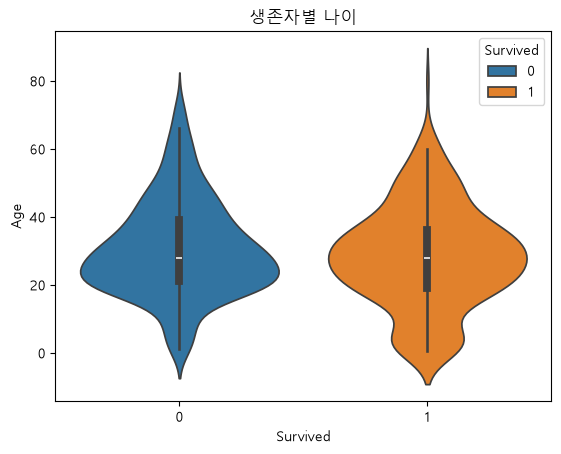

In [9]:
sns.violinplot(titanic_df, x="Survived", y="Age", hue="Survived")
plt.title("생존자별 나이")
plt.show()

보통 나이 분포가 10대후반 - 40대 이하 쯤으로 분포가 많이 되어있는걸 보아
평균값으로 결측치를 채워도 데이터의 전체적인 경향이 크게 달라지지 않을 것 같음

In [10]:
titanic_df["Age"] = titanic_df["Age"].fillna(titanic_df["Age"].median())

나이가 소수형으로 되어있어서 깔끔하게 만들기 위해 정수형으로 변경

In [11]:
titanic_df["Age"] = titanic_df["Age"].astype(int)
titanic_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    int64  
 3   Age       891 non-null    int64  
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
dtypes: float64(1), int64(6)
memory usage: 48.9 KB


잘 채워진것을 확인할 수 있음

기존에 SibSp, Parch가 따로 있는 것보다 FamilySize라는 하나의 변수로 합치면 가족 규모와 생존 여부의 관계를 분석하기 쉬워질 수 있을것 같음
파생변수 만들기

In [12]:
titanic_df["FamilySize"] = titanic_df["SibSp"] + titanic_df["Parch"] + 1
titanic_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize
0,0,3,0,22,1,0,7.2500,2
1,1,1,1,38,1,0,71.2833,2
2,1,3,1,26,0,0,7.9250,1
3,1,1,1,35,1,0,53.1000,2
4,0,3,0,35,0,0,8.0500,1


각 수치의 상관관계를 확인해보기

In [13]:
corr_matrix = titanic_df.corr(numeric_only=True)
corr_matrix

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize
Survived,1.000000,-0.338481,0.543351,-0.064909,-0.035322,0.081629,0.257307,0.016639
Pclass,-0.338481,1.000000,-0.131900,-0.339999,0.083081,0.018443,-0.549500,0.065997
Sex,0.543351,-0.131900,1.000000,-0.080750,0.114631,0.245489,0.182333,0.200988
Age,-0.064909,-0.339999,-0.080750,1.000000,-0.233066,-0.172745,0.096838,-0.245593
SibSp,-0.035322,0.083081,0.114631,-0.233066,1.000000,0.414838,0.159651,0.890712
Parch,0.081629,0.018443,0.245489,-0.172745,0.414838,1.000000,0.216225,0.783111
Fare,0.257307,-0.549500,0.182333,0.096838,0.159651,0.216225,1.000000,0.217138
FamilySize,0.016639,0.065997,0.200988,-0.245593,0.890712,0.783111,0.217138,1.000000


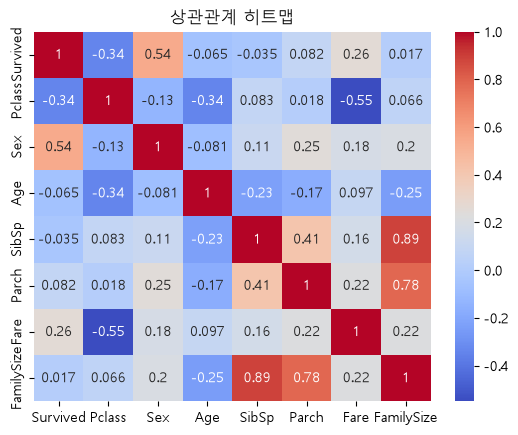

In [14]:
# 시각화 하기
sns.heatmap(corr_matrix, cmap="coolwarm", annot=True)
plt.title("상관관계 히트맵")
plt.show()

In [28]:
# Survived 클래스 비율(생존/사망 비율) 알아보기
titanic_is_survived = (titanic_df["Survived"].value_counts(normalize=True) * 100).round(2)
titanic_is_survived

# 전체 승객 중 사망자는 약 61.6%, 생존자는 약 38.4%로 사망자의 비율이 생존자보다 높음.

Survived
0    61.62
1    38.38
Name: proportion, dtype: float64

FamilySize와 SibSp, Parch는 서로 상당히 비슷한 정보를 가지고 있음

모델에 데이터를 학습시키기 위해 데이터 분할

In [15]:
X = titanic_df.drop("Survived", axis=1)
X.head()
y = titanic_df["Survived"]
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2026, stratify=y)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(712, 7) (179, 7) (712,) (179,)


stratify=y : 계층화 적용을 해야함
적용을 하지않으면 데이터를 나눌때 생존,사망 비율이 랜덤하게 들어갈 수 있기 때문에 
학습 데이터와 테스트 데이터의 생존,사망 비율을 원본 데이터와 비슷하게 유지하기 위함

타이타닉 데이터는 Age, Fare 등 변수마다 값의 범위가 다르기 때문에, 
특정 변수의 값이 다른 변수보다 모델에 더 큰 영향을 주지 않도록 각 변수의 데이터를 표준화함

In [17]:
scaler = StandardScaler()

#표준화
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 2 단계, 모델 준비

In [18]:
from sklearn.neighbors import KNeighborsClassifier

In [19]:
kn = KNeighborsClassifier(n_neighbors=5)

## 3단계, 모델학습

### 하이퍼 파라미터(Hyper Parameter)
- 사람(개발자 또는 분석가)가 필요에 따라 직접 설정하는 파라미터의 값을 의미한다

### 파라미터(Parameter)
- 모델이 학습(fit)을 통해 스스로 찾아내는 값을 의미한다

In [20]:
# 학습
kn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [21]:
# 모델 예측
y_pred = kn.predict(X_test_scaled)
y_pred[:10]

array([0, 0, 1, 0, 0, 0, 1, 1, 0, 1])

## 4단계, 모델평가

In [22]:
train_score = kn.score(X_train_scaled, y_train)
test_score = kn.score(X_test_scaled, y_test)

print(f"훈련 데이터 정확도 점수 : {train_score:.2f}")
print(f"테스트 데이터 정확도 점수 : {test_score:.2f}")

print(f"모델 정확도 점수: {accuracy_score(y_pred, y_test)}")

훈련 데이터 정확도 점수 : 0.87
테스트 데이터 정확도 점수 : 0.82
모델 정확도 점수: 0.8156424581005587


In [23]:
cm = confusion_matrix(y_pred, y_test)
cm

array([[95, 18],
       [15, 51]])

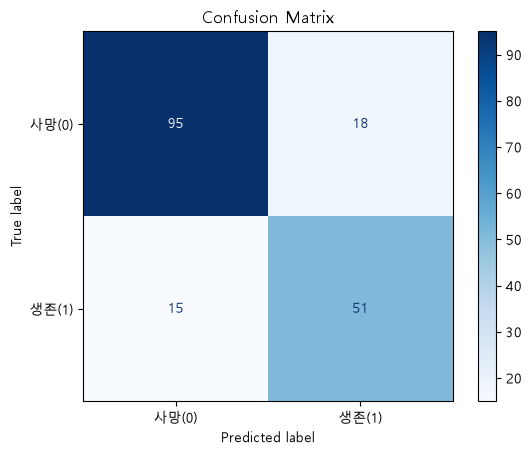

In [24]:
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["사망(0)", "생존(1)"],)
display.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

Confusion Matrix를 통해 실제 사망자와 생존자를 각각 얼마나 정확하게 예측했는지 확인할 수 있음
위왼쪽부터 오른쪽 아래로 대각선 값은 올바르게 예측한 경우이고, 대각선 이외의 값은 잘못 예측한 경우임

## 생존자를 사망으로 예측하는 것과 사망자를 생존자로 예측하는 것 중 어떠한 오류가 더 치명적일까?

Confusion Matrix 그래프를 확인 했을 때     
실제로 생존했지만 사망한 경우 -> 21개  
실제로 사망했지만 생존으로 예측한 경우 -> 12개  
  
생존자를 사망으로 잘못 예측한 경우가 사망자를 생존으로 잘못 예측한 경우가 더 많아 생존자를 사망으로 잘못 예측한 경우가 더 치명적이라고 볼 수 있음

① 사망자가 생존자보다 많았다.
② 성별에 따라 생존율에 차이가 나타났다.
③ 객실 등급에 따라 생존율에 차이가 나타났다.

타이타닉 생존 여부는 0과 1로 구분하는 이진 분류 문제이므로 KNN 분류 모델을 선택하였다. 데이터의 변수 간 스케일 차이를 줄이기 위해 StandardScaler로 표준화한 후 학습하였다. 또한 n_neighbors 값을 변경하여 성능을 비교하는 방식으로 하이퍼파라미터 튜닝을 진행하였다.

In [53]:
kn2 = KNeighborsClassifier(n_neighbors=10)

# 학습
kn2.fit(X_train_scaled, y_train)

# 평가
train_score2 = kn2.score(X_train_scaled, y_train)
test_score2 = kn2.score(X_test_scaled, y_test)

print(f"훈련 데이터 정확도 점수 : {train_score2:.2f}")
print(f"테스트 데이터 정확도 점수 : {test_score2:.2f}")

훈련 데이터 정확도 점수 : 0.83
테스트 데이터 정확도 점수 : 0.83
